# Ex.No.1 - Univariate, Bivariate and Multivariate Analysis

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 03/01/2026_

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [90]:
# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


# Univariate Analysis

In [91]:
# Statistical summary
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [92]:
# Build summary table
summary_table = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Mode": df.mode().iloc[0],
    "Variance": df.var(),
    "Std Dev": df.std(),
    "Skewness": df.skew(),
    "Kurtosis": df.kurt(),
    "Min": df.min(),
    "Max": df.max(),
    "Range": df.max() - df.min(),
    "Q1 (25%)": df.quantile(0.25),
    "Q2 (50%)": df.quantile(0.50),
    "Q3 (75%)": df.quantile(0.75)
})

print(summary_table)

                       Mean  Median  Mode  Variance   Std Dev  Skewness  \
sepal length (cm)  5.843333    5.80   5.0  0.685694  0.828066  0.314911   
sepal width (cm)   3.057333    3.00   3.0  0.189979  0.435866  0.318966   
petal length (cm)  3.758000    4.35   1.4  3.116278  1.765298 -0.274884   
petal width (cm)   1.199333    1.30   0.2  0.581006  0.762238 -0.102967   

                   Kurtosis  Min  Max  Range  Q1 (25%)  Q2 (50%)  Q3 (75%)  
sepal length (cm) -0.552064  4.3  7.9    3.6       5.1      5.80       6.4  
sepal width (cm)   0.228249  2.0  4.4    2.4       2.8      3.00       3.3  
petal length (cm) -1.402103  1.0  6.9    5.9       1.6      4.35       5.1  
petal width (cm)  -1.340604  0.1  2.5    2.4       0.3      1.30       1.8  


In [93]:
# Map species names
df["species_name"] = iris.target
df["species_name"] = df["species_name"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Split data by species
sertosa = df.loc[df['species_name'] == 'Setosa']
versicolor = df.loc[df['species_name'] == 'Versicolor']
virginica = df.loc[df['species_name'] == 'Virginica']

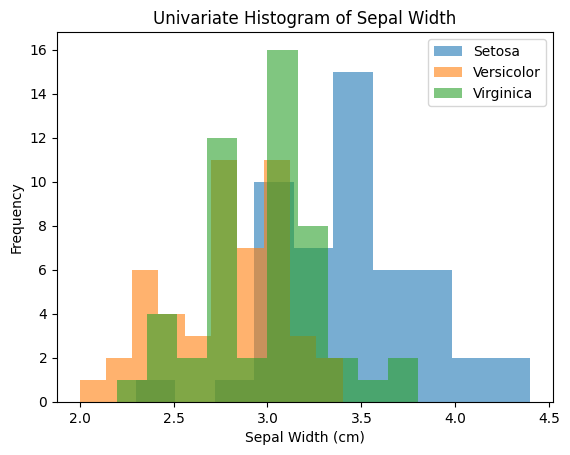

In [94]:
# Univariate Analysis - Histogram
plt.hist(setosa["sepal width (cm)"], bins=10, alpha=0.6, label="Setosa")
plt.hist(versicolor["sepal width (cm)"], bins=10, alpha=0.6, label="Versicolor")
plt.hist(virginica["sepal width (cm)"], bins=10, alpha=0.6, label="Virginica")

plt.xlabel("Sepal Width (cm)")
plt.ylabel("Frequency")
plt.title("Univariate Histogram of Sepal Width")
plt.legend()
plt.show()

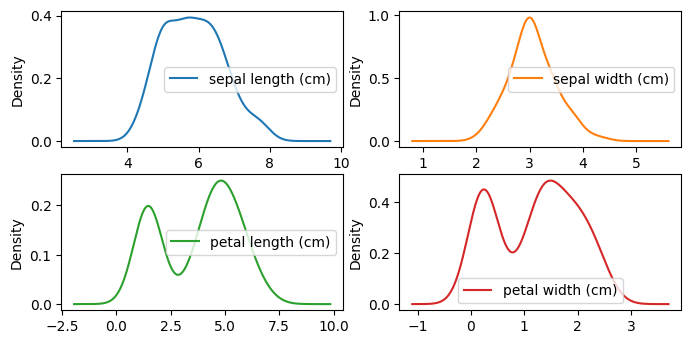

In [95]:
# Univariate Analysis - Density Plot
df.plot(kind='density', subplots=True, layout=(3,2), figsize=(8,6), sharex=False)
plt.show()

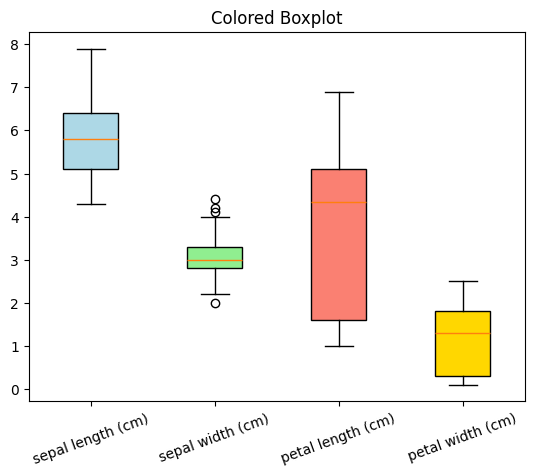

In [99]:
# Univariate Analysis - Box Plot
data = df.select_dtypes(include='number')
box = plt.boxplot(data.values, patch_artist=True)

# Apply colors safely
colors = ['lightblue', 'lightgreen', 'salmon', 'gold']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(range(1, len(data.columns)+1), data.columns, rotation=20)
plt.title("Colored Boxplot")
plt.show()

In [103]:
# Univariate Analysis - Frequency Table
freq_table = pd.DataFrame()

for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        # Numeric → binning
        freq = df[col].value_counts(bins=5, sort=False)
    else:
        # Categorical → direct counts
        freq = df[col].value_counts()

    freq_table[col] = freq

print("Frequency Table")
print(freq_table.fillna(0))

Frequency Table
               sepal length (cm)  sepal width (cm)  petal length (cm)  \
(4.295, 5.02]                 32               0.0                0.0   
(5.02, 5.74]                  41               0.0                0.0   
(5.74, 6.46]                  42               0.0                0.0   
(6.46, 7.18]                  24               0.0                0.0   
(7.18, 7.9]                   11               0.0                0.0   

               petal width (cm)  species_name  
(4.295, 5.02]               0.0           0.0  
(5.02, 5.74]                0.0           0.0  
(5.74, 6.46]                0.0           0.0  
(6.46, 7.18]                0.0           0.0  
(7.18, 7.9]                 0.0           0.0  


# Bivariate Analysis

In [109]:
# Bivariate Analysis - Correlation Matrix
corr = df.corr(numeric_only=True)
print(corr)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


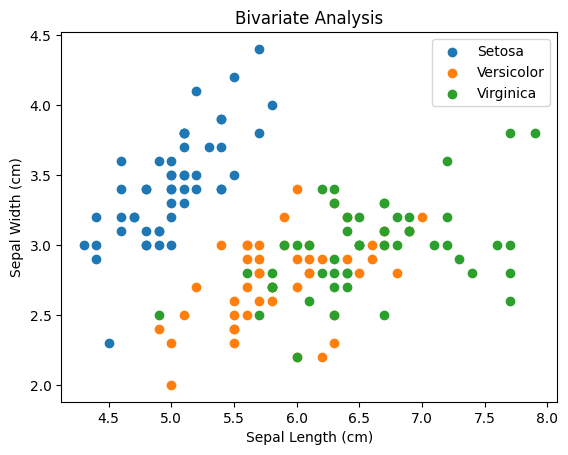

In [3]:
# Bivariate Analysis - Scatter Plot
plt.scatter(setosa["sepal length (cm)"],
            setosa["sepal width (cm)"],
            label="Setosa")

plt.scatter(versicolor["sepal length (cm)"],
            versicolor["sepal width (cm)"],
            label="Versicolor")

plt.scatter(virginica["sepal length (cm)"],
            virginica["sepal width (cm)"],
            label="Virginica")

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Bivariate Analysis")
plt.legend()
plt.show()

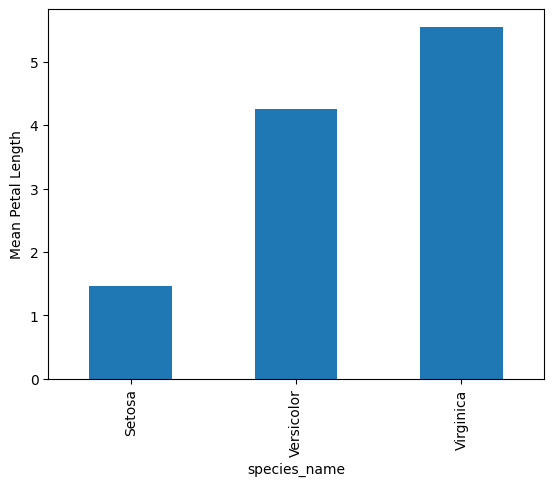

In [107]:
# Bivariate Analysis - Bar Plot
df.groupby('species_name')['petal length (cm)'].mean().plot(kind='bar')
plt.ylabel("Mean Petal Length")
plt.show()

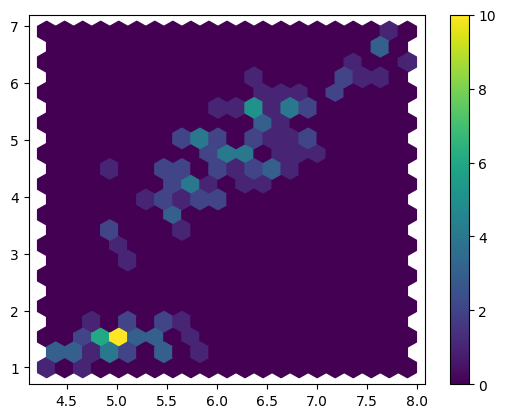

In [108]:
# Bivariate Analysis - Hexbin Plot
plt.hexbin(df['sepal length (cm)'],
           df['petal length (cm)'],
           gridsize=20)
plt.colorbar()
plt.show()


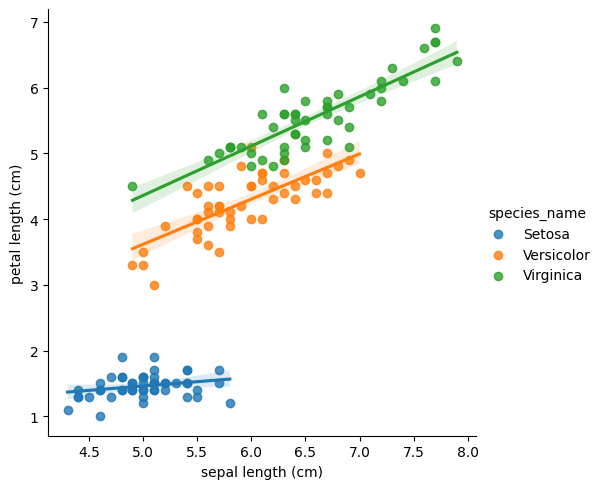

In [30]:
# Bivariate Analysis - Line plot
sns.lmplot(x='sepal length (cm)',
           y='petal length (cm)',
           hue='species_name',
           data=df)
plt.show()


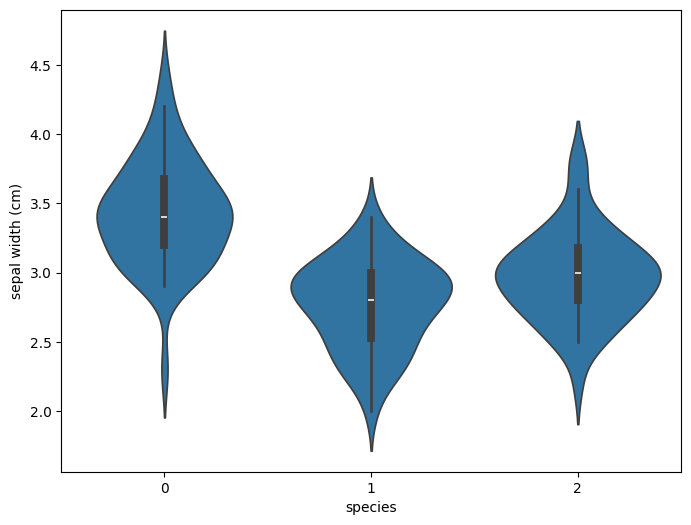

In [32]:
# Bivariate Analysis - Violin plot
plt.figure(figsize=(8,6))
sns.violinplot(x='species', y='sepal width (cm)', data=df)
plt.show()


# Multivariate Analysis

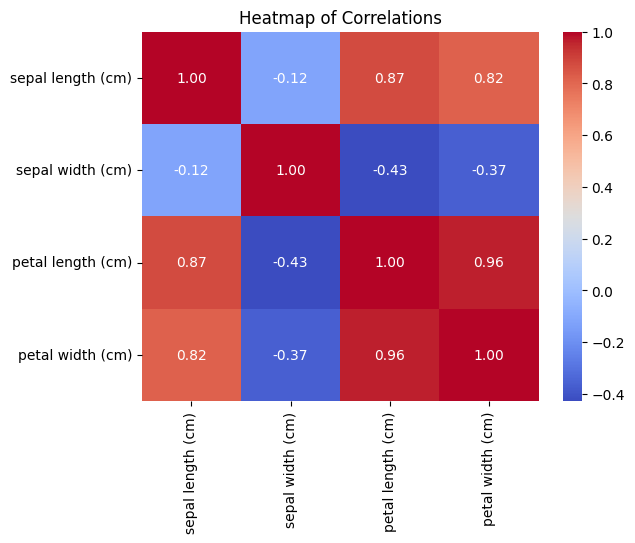

In [6]:
# Multivariate Analysis - Correlation HeatMap

corr_matrix = df.iloc[:, :-2].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Heatmap of Correlations")
plt.show()

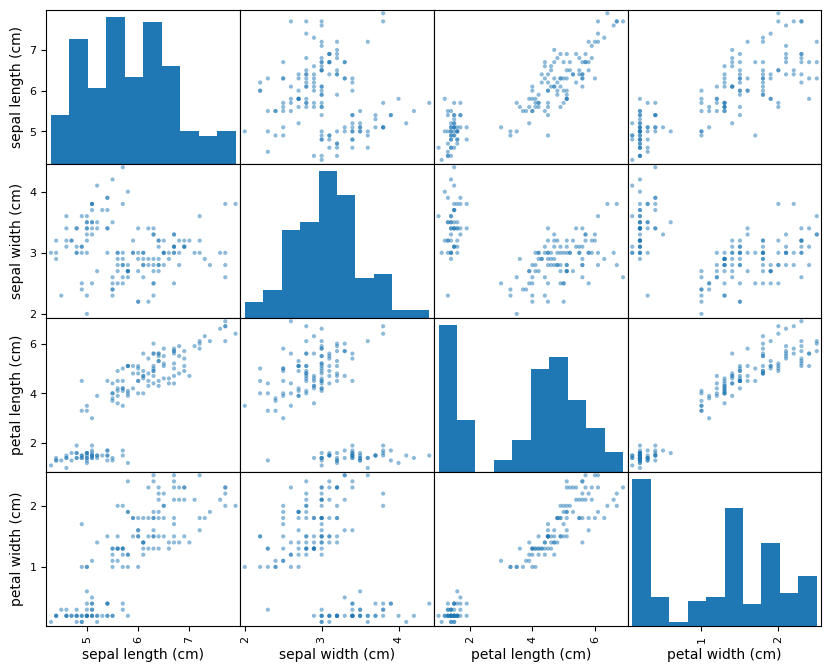

In [110]:
# Multivariate Analysis - Pairwise Scatter Matrix
pd.plotting.scatter_matrix(df, figsize=(10,8))
plt.show()